Events: 16

=== Gas-only model ===


C:\Users\smumm\AppData\Local\Temp\ipykernel_1552\838925319.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  survival_base = df.groupby('battery_id').apply(compute_survival)
C:\Users\smumm\AppData\Local\Temp\ipykernel_1552\838925319.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features = df.groupby('battery_id').apply(extract_features)


<lifelines.CoxPHFitter: fitted with 23 total observations, 7 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.2
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 23
number of events observed = 16
   partial log-likelihood = -31.46
         time fit was run = 2026-04-20 02:31:06 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
gas_early  0.50      1.64      0.26           -0.02            1.01                0.98                2.75
gas_max    0.41      1.51      0.32           -0.22            1.04                0.80                2.84
gas_slope  0.04      1.05      0.33           -0.60            0.69                0.55                2.00

           cmp to    z    p  -log2(p)
covariate                            
gas_early    0.00 1.89 0.06      4.10
gas_max      0.00 1.27 0.20      2.29
gas_slope    0.00 0.13 0.89      0.16
---
Concordance = 0.80
Partial AIC = 68.93
log-likelihood ratio test = 6.95 on 3 df
-log2(p) of ll-ratio test = 3.77


=== Impedance-only model ===


<lifelines.CoxPHFitter: fitted with 23 total observations, 7 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.2
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 23
number of events observed = 16
   partial log-likelihood = -26.21
         time fit was run = 2026-04-20 02:31:06 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Re_early   0.84      2.33      0.30            0.26            1.43                1.29                4.19
Rct_early  0.64      1.90      0.27            0.11            1.17                1.12                3.23

           cmp to    z      p  -log2(p)
covariate                              
Re_early     0.00 2.81 <0.005      7.65
Rct_early    0.00 2.38   0.02      5.86
---
Concordance = 0.93
Partial AIC = 56.42
log-likelihood ratio test = 17.46 on 2 df
-log2(p) of ll-ratio test = 12.60


=== Combined gas + impedance model ===


<lifelines.CoxPHFitter: fitted with 23 total observations, 7 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.2
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 23
number of events observed = 16
   partial log-likelihood = -24.76
         time fit was run = 2026-04-20 02:31:06 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
gas_early  0.37      1.44      0.26           -0.14            0.87                0.87                2.40
gas_max    0.18      1.20      0.34           -0.48            0.85                0.62                2.34
gas_slope -0.10      0.91      0.35           -0.78            0.58                0.46                1.79
Re_early   0.85      2.33      0.34            0.19            1.50                1.21                4.49
Rct_early  0.63      1.87      0.36           -0.07            1.33                0.93                3.77

           cmp to     z    p  -log2(p)
covariate                             
gas_early    0.00  1.42 0.16      2.67
gas_max      0.00  0.54 0.59      0.77
gas_slope    0.00 -0.28 0.78      0.36
Re_early     0.00  2.52 0.01      6.41
Rct_early    0.00  1.76 0.08      3.67
---
Concordance = 0.96
Partial AIC = 59.53
log-likelihood ratio test = 20.35 on 5 df
-log2(p) of ll-ratio test = 9.87

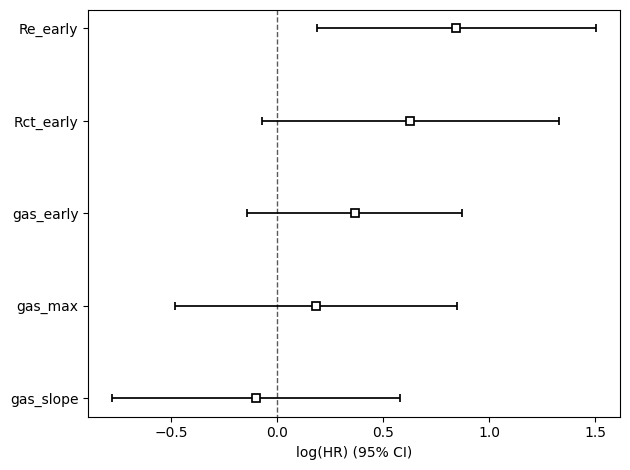

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter

# Use Day1's processed dataset, which includes SoH and engineered features.
df = pd.read_csv('nasa_processed.csv')

# Step 2: create time-to-event outcome properly.
def compute_survival(g):
    g = g.sort_values('test_id')
    failure = g[g['SoH'] < 85]
    if len(failure) > 0:
        duration = failure['test_id'].iloc[0]
        event = 1
    else:
        duration = g['test_id'].max()
        event = 0
    return pd.Series({'duration': duration, 'event': event})

survival_base = df.groupby('battery_id').apply(compute_survival)

# Step 3: extract early-life + spike + trend features.
def extract_features(g):
    g = g.sort_values('test_id')
    early = g.iloc[:10]
    return pd.Series({
        'gas_early': early['gas_ppm'].mean(),
        'gas_max': g['gas_ppm'].max(),
        'gas_slope': np.polyfit(g['test_id'], g['gas_ppm'], 1)[0],
        'Re_early': early['Re'].mean(),
        'Rct_early': early['Rct'].mean(),
    })

features = df.groupby('battery_id').apply(extract_features)

survival_df = survival_base.join(features).reset_index(drop=True)
print('Events:', survival_df['event'].sum())

# Step 4: normalize the predictors.
gas_cols = ['gas_early', 'gas_max', 'gas_slope']
impedance_cols = ['Re_early', 'Rct_early']
all_cols = gas_cols + impedance_cols

scaler = StandardScaler()
survival_df[all_cols] = scaler.fit_transform(survival_df[all_cols])

# Step 5: fit comparison Cox models.
main_df = survival_df[['duration', 'event'] + all_cols].replace([np.inf, -np.inf], np.nan).dropna()

print('\n=== Gas-only model ===')
cph_gas = CoxPHFitter(penalizer=0.2)
cph_gas.fit(
    main_df[['duration', 'event'] + gas_cols],
    duration_col='duration',
    event_col='event'
 )
cph_gas.print_summary()

print('\n=== Impedance-only model ===')
cph_impedance = CoxPHFitter(penalizer=0.2)
cph_impedance.fit(
    main_df[['duration', 'event'] + impedance_cols],
    duration_col='duration',
    event_col='event'
 )
cph_impedance.print_summary()

print('\n=== Combined gas + impedance model ===')
cph = CoxPHFitter(penalizer=0.2)
cph.fit(
    main_df[['duration', 'event'] + all_cols],
    duration_col='duration',
    event_col='event'
 )
cph.print_summary()
cph.plot()
plt.tight_layout()
plt.show()



Gradient Boosting Algorithm

MAE: 41.41 cycles
R2:  0.809


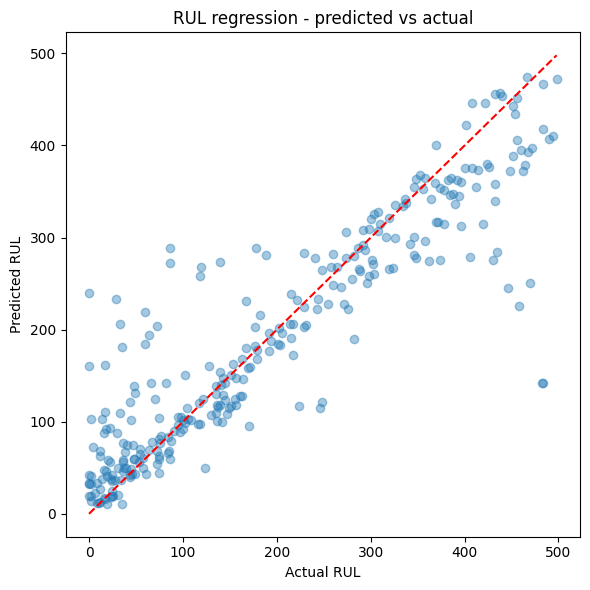

Saved scaler and regressor.


In [10]:
from pathlib import Path
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Keep Cell 2 runnable even if Cell 1 has not been executed in this kernel.
if 'df' not in globals():
    df = pd.read_csv('nasa_processed.csv')

SENSOR_FEATURES = [
    'Re', 'Rct',
    'capacity_fade', 'cumulative_fade',
    'ambient_temperature', 'gas_ppm', 'smoke_density'
 ]

df_s = df.sort_values(['battery_id', 'test_id']).copy()
df_s['rul'] = df_s.groupby('battery_id')['test_id'].transform(
    lambda x: x.max() - x)

scaler = StandardScaler()
X_rul = pd.DataFrame(
    scaler.fit_transform(df_s[SENSOR_FEATURES]),
    columns=SENSOR_FEATURES)
y_rul = df_s['rul']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_rul, y_rul, test_size=0.2, random_state=42)

reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
reg.fit(X_tr, y_tr)
y_pred_rul = reg.predict(X_te)

print(f'MAE: {mean_absolute_error(y_te, y_pred_rul):.2f} cycles')
print(f'R2:  {r2_score(y_te, y_pred_rul):.3f}')

plt.figure(figsize=(6, 6))
plt.scatter(y_te, y_pred_rul, alpha=0.4)
plt.plot([0, y_te.max()], [0, y_te.max()], 'r--')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('RUL regression - predicted vs actual')
plt.tight_layout()
plt.savefig('data/rul_regression.png', dpi=150)
plt.show()

Path('pipeline').mkdir(exist_ok=True)
joblib.dump(scaler, 'pipeline/scaler.pkl')
joblib.dump(reg, 'pipeline/regressor.pkl')
print('Saved scaler and regressor.')

In [11]:
print('=== RUL regression performance by temperature condition ===')

from sklearn.metrics import mean_absolute_error, r2_score

for temp in sorted(df['ambient_temperature'].unique()):
    mask = df['ambient_temperature'] == temp
    if mask.sum() < 20:
        continue

    df_temp = df[mask].sort_values(['battery_id', 'test_id']).copy()
    df_temp['rul'] = df_temp.groupby('battery_id')['test_id'].transform(
        lambda x: x.max() - x)

    X_temp = pd.DataFrame(
        scaler.transform(df_temp[SENSOR_FEATURES]),
        columns=SENSOR_FEATURES)
    y_temp = df_temp['rul']
    preds = reg.predict(X_temp)

    print(f'Temp: {temp}C  (n={len(df_temp)})')
    print(f'  MAE: {mean_absolute_error(y_temp, preds):.2f} cycles')
    print(f'  R2 : {r2_score(y_temp, preds):.3f}')
    print('-' * 45)

=== RUL regression performance by temperature condition ===
Temp: 24C  (n=1408)
  MAE: 33.02 cycles
  R2 : 0.878
---------------------------------------------
Temp: 43C  (n=64)
  MAE: 12.47 cycles
  R2 : 0.682
---------------------------------------------
